In [10]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('src'))

from plot_utils import calculate_bt_convergence, better_color_map
import alternatives

# Set style
sns.set_theme(style="whitegrid")

# Configuration
experiments = ['qwen7_stocks', 'qwen7_ticker']
methods = ['ppl', 'single', 'group']
method_labels = {
    'ppl': 'Perplexity (Winner: Lower PPL/Higher Score)',
    'single': 'Single Token Prob (Winner: Higher Prob)',
    'group': 'Group Prob (Winner: Higher Prob)'
}

In [5]:
def run_convergence_analysis(experiment_name):
    print(f"Running analysis for {experiment_name}...")
    results = {}
    
    for method in methods:
        print(f"  Calculating for method: {method}")
        df = calculate_bt_convergence(experiment_name, method=method)
        if df is not None:
            results[method] = df
            
    return results

def plot_convergence(results, title, color_map):
    if not results:
        print(f"No results for {title}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
    
    for i, method in enumerate(methods):
        ax = axes[i]
        if method in results:
            df = results[method]
            
            alternatives_col_names = [c for c in df.columns if c not in ['iteration', 'num_templates']]
            assert set(alternatives_col_names).issubset(set(color_map.keys())), "Data columns do not match color map keys"
            
            for alternative, color in color_map.items():
                if alternative in alternatives_col_names:
                    ax.plot(df['iteration'], df[alternative], label=alternative, 
                            color=better_color_map.get(color, color), linewidth=2)
            
            ax.set_title(method_labels[method])
            ax.set_xlabel("Iteration (Templates)")
            ax.grid(True, linestyle='--', alpha=0.7)
            
            if i == 0:
                ax.set_ylabel("BT Probability ($e^\\beta$)")
        else:
            ax.text(0.5, 0.5, "No Data", ha='center')
            
    # Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', title="Options")
    plt.suptitle(f"Convergence Comparison: {title}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

def plot_final_weights(results, title, color_map):
    if not results:
        return

    # Consolidate final weights
    final_data = []
    
    for method, df in results.items():
        if df is not None and not df.empty:
            last_row = df.iloc[-1]
            alternatives_col_names = [c for c in df.columns if c not in ['iteration', 'num_templates']]
            assert set(alternatives_col_names).issubset(set(color_map.keys())), "Data columns do not match color map keys"
            
            for col in alternatives_col_names:
                final_data.append({
                    'Option': col,
                    'Probability': last_row[col],
                    'Method': method
                })
    
    if not final_data:
        print("No final data to plot.")
        return

    df_final = pd.DataFrame(final_data)
    
    plt.figure(figsize=(14, 6))
    
    # Sort options by average probability across methods for cleaner plot
    order = df_final.groupby('Option')['Probability'].mean().sort_values(ascending=False).index
    
    # Create palette
    palette = {}
    for alternative in order:
        palette[alternative] = better_color_map.get(color_map.get(alternative, ''), 'gray')
    sns.barplot(data=df_final, x='Method', y='Probability', hue='Option', hue_order=order, palette=palette)

    plt.title(f"Final Weights Comparison: {title}")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Option')
    plt.tight_layout()
    plt.show()

Running analysis for qwen7_stocks...
  Calculating for method: ppl
Loading cached convergence data from experiments/qwen7_stocks/bt_convergence_ppl.csv
  Calculating for method: single
Loading cached convergence data from experiments/qwen7_stocks/bt_convergence_single.csv
  Calculating for method: group
Loading cached convergence data from experiments/qwen7_stocks/bt_convergence_group.csv


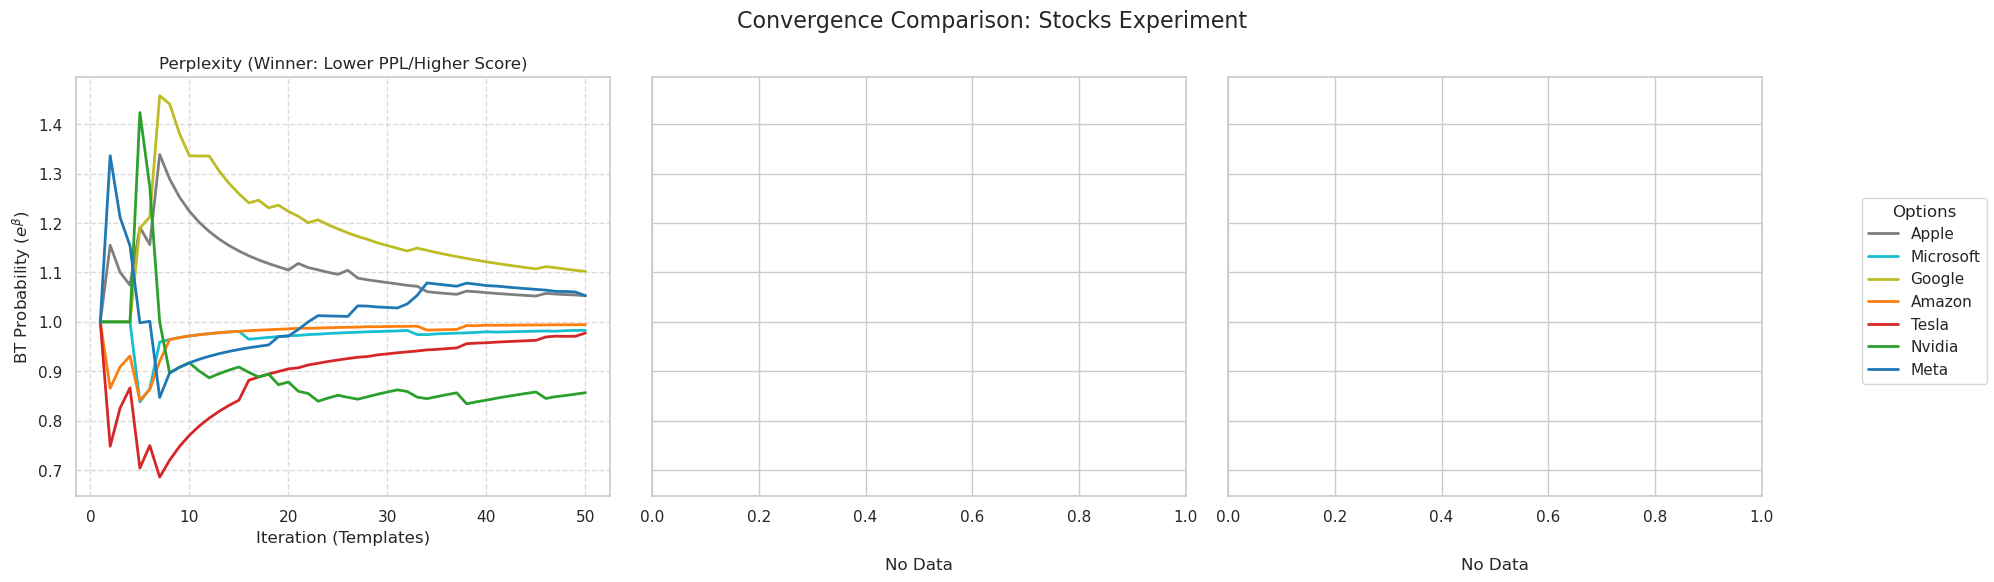

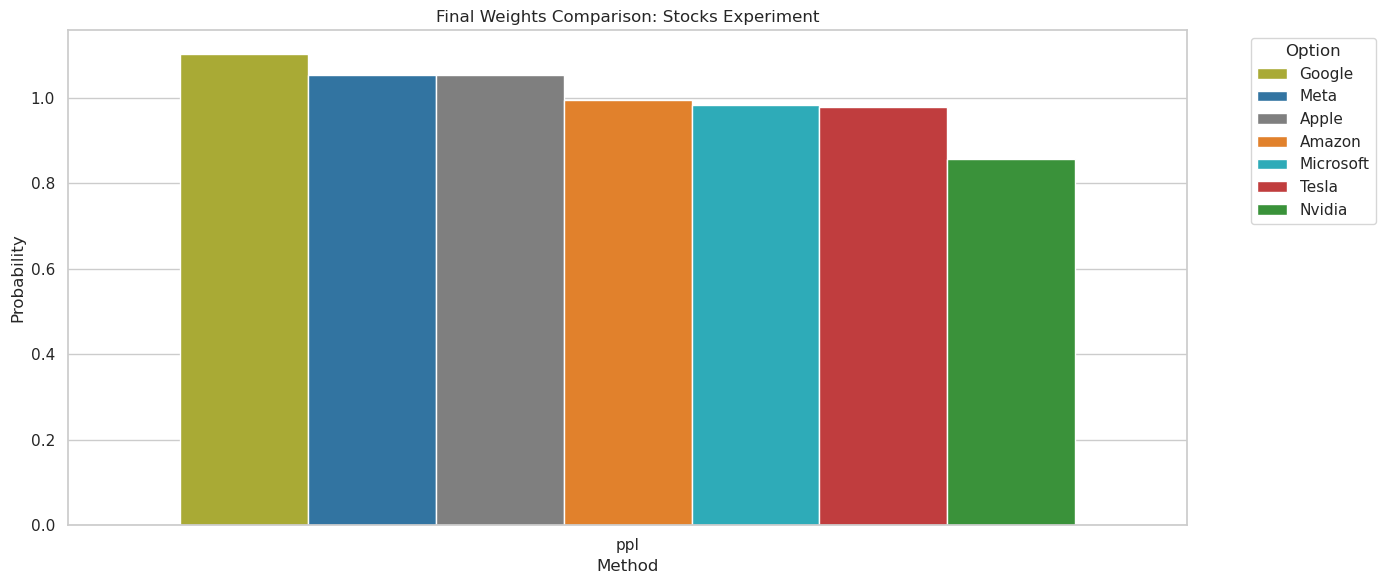

In [13]:
# Analyze Stocks Experiment
exp_stocks = 'qwen7_stocks'
results_stocks = run_convergence_analysis(exp_stocks)
# The second argument is now 'title', so we can pass a descriptive title if desired, or still pass the experiment name.
plot_convergence({'ppl': results_stocks['ppl']}, title="Stocks Experiment", color_map=alternatives.stocks)
plot_final_weights({'ppl': results_stocks['ppl']}, title="Stocks Experiment", color_map=alternatives.stocks)

Running analysis for qwen7_ticker...
  Calculating for method: ppl
Loading cached convergence data from experiments/qwen7_ticker/bt_convergence_ppl.csv
  Calculating for method: single
Loading cached convergence data from experiments/qwen7_ticker/bt_convergence_single.csv
  Calculating for method: group
Loading cached convergence data from experiments/qwen7_ticker/bt_convergence_group.csv


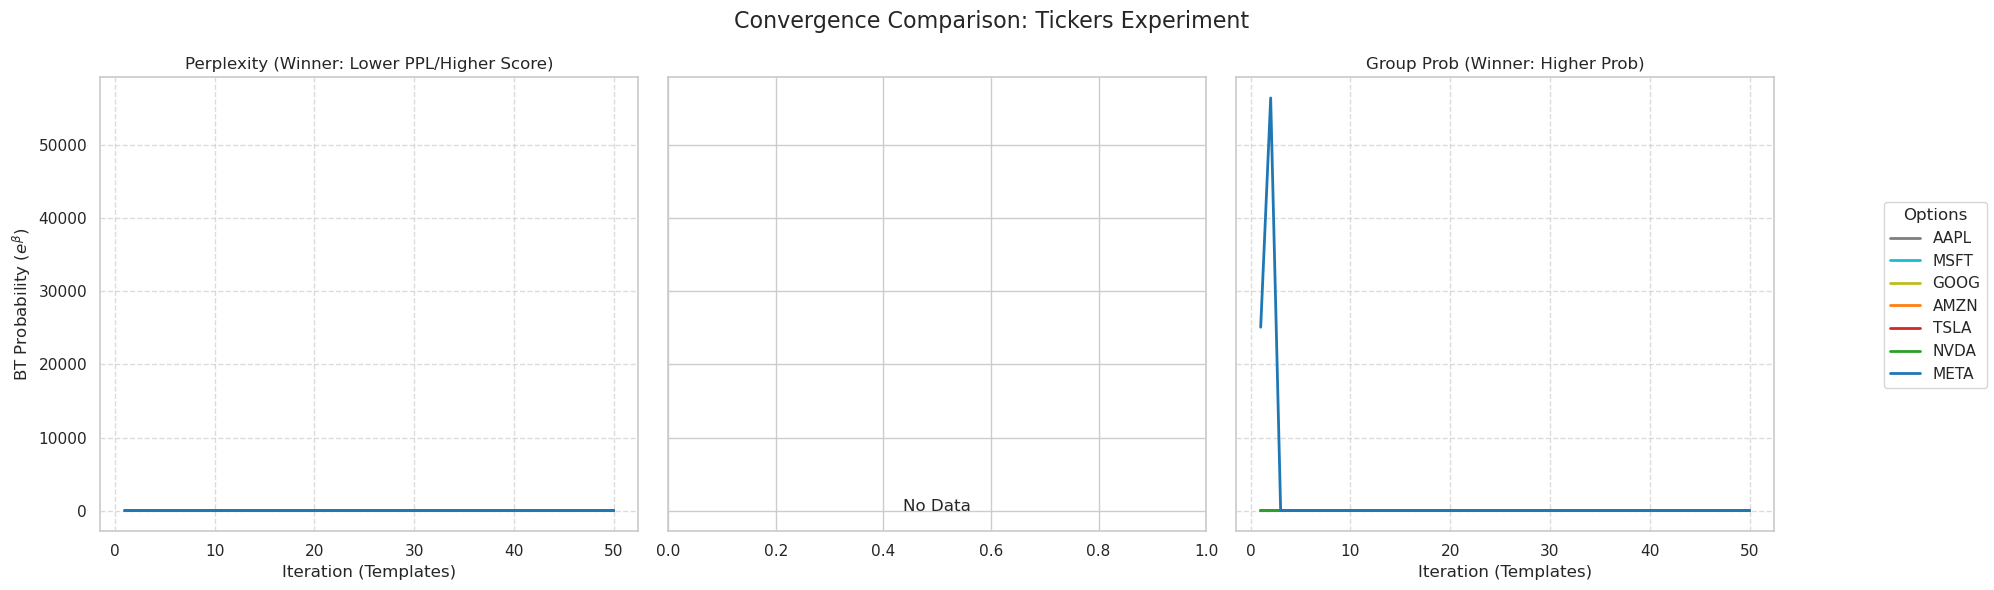

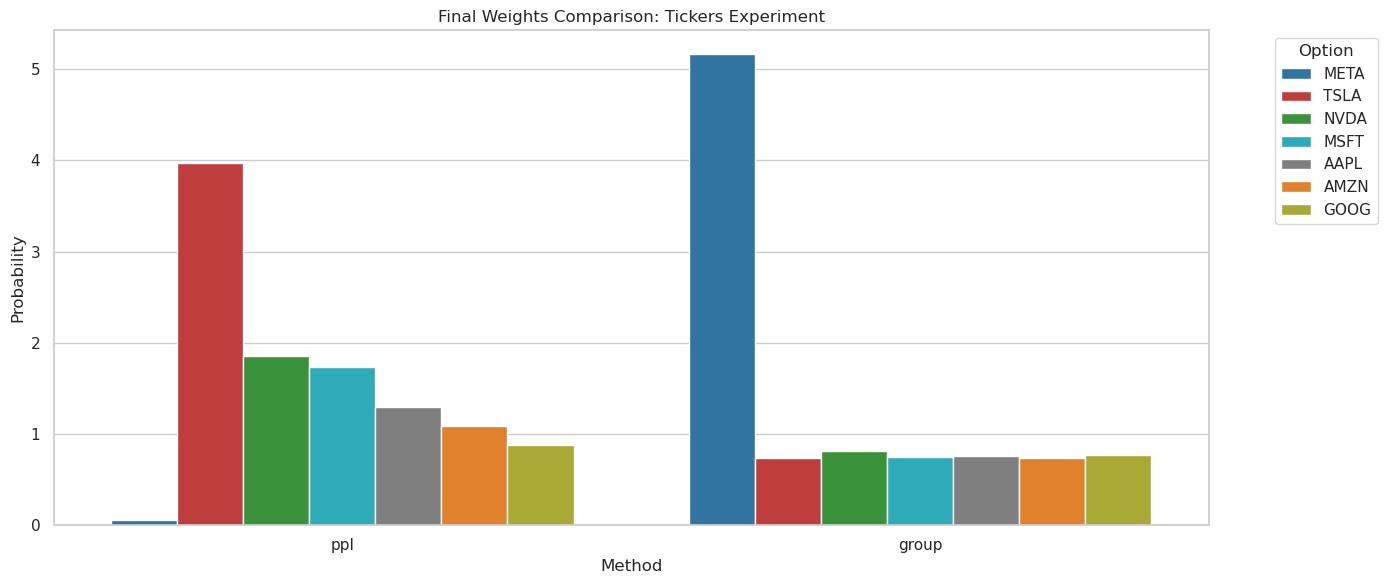

In [16]:
# Analyze Tickers Experiment
exp_tickers = 'qwen7_ticker'
results_tickers = run_convergence_analysis(exp_tickers)
results_tickers_ppl = {
    'ppl': results_tickers['ppl'],
    'group': results_tickers['group']
}
plot_convergence(results_tickers_ppl, title="Tickers Experiment", color_map=alternatives.tickers)
plot_final_weights(results_tickers_ppl, title="Tickers Experiment", color_map=alternatives.tickers)